# IMPORT CÁC THƯ VIỆN CẦN THIẾT 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

In [4]:
print("Dataset Shape:")
print(df.shape)
print("\nDataset Info:")
print(df.info())

Dataset Shape:
(250000, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None


In [5]:
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nDuplicated Rows:")
print(df.duplicated().sum())
print("\nNumrical Features Summary Stats:")
print(df.describe())


Missing Values per Column:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Duplicated Rows:
0

Numrical Features Summary Stats:
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


# Kiểm tra Outliers

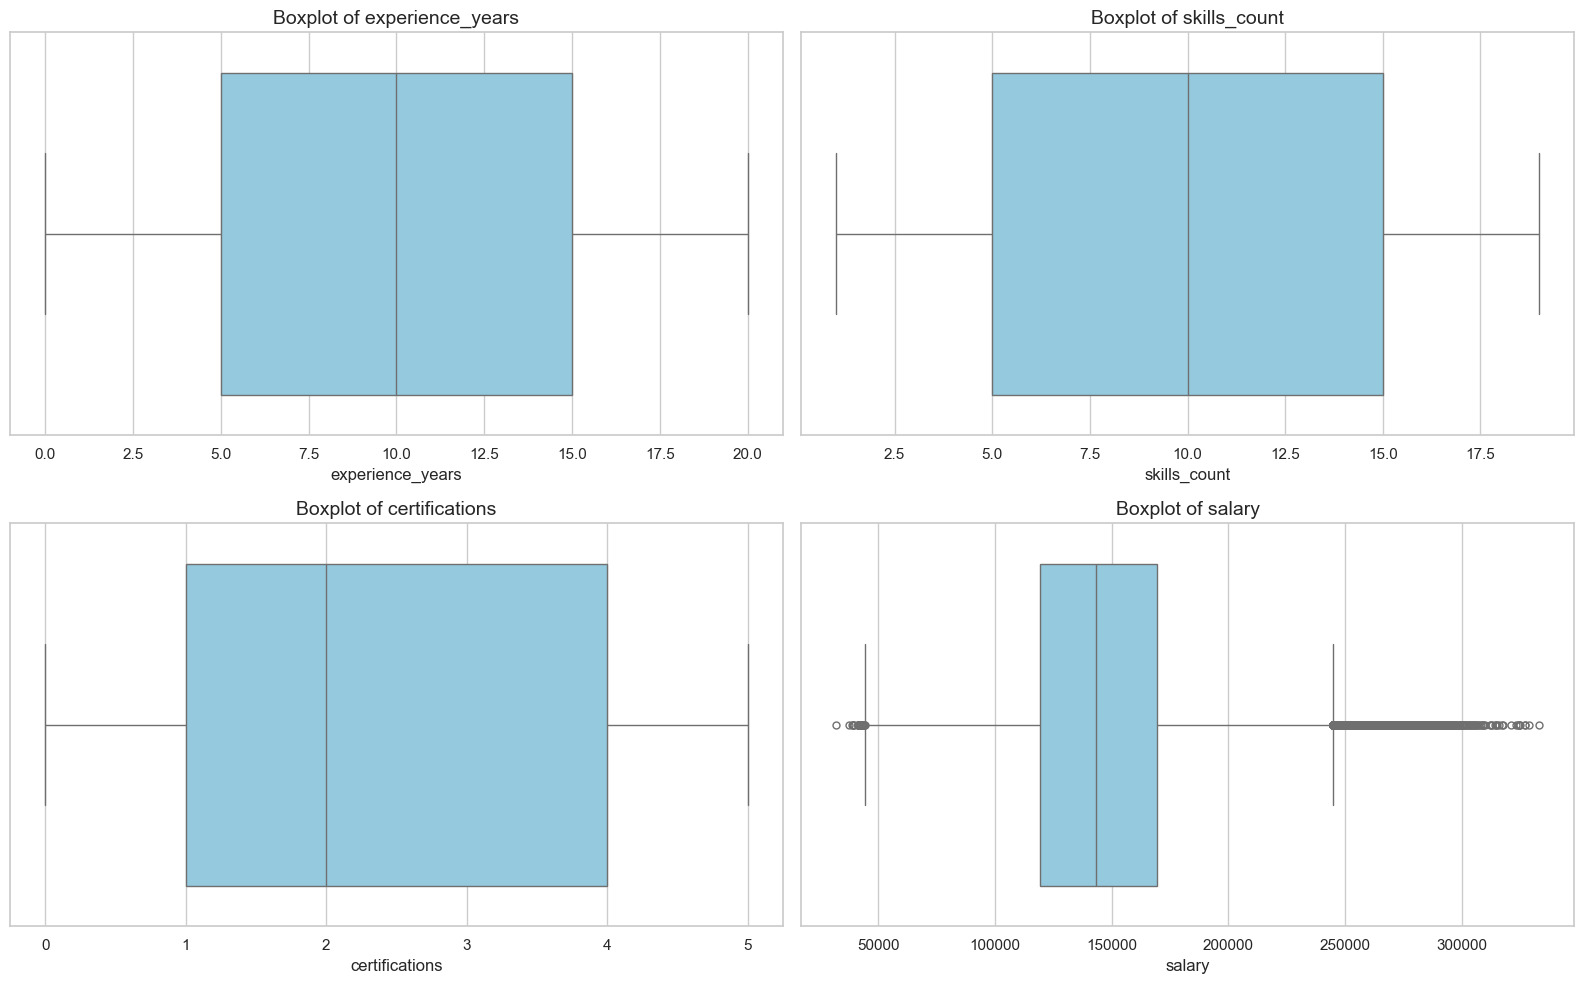

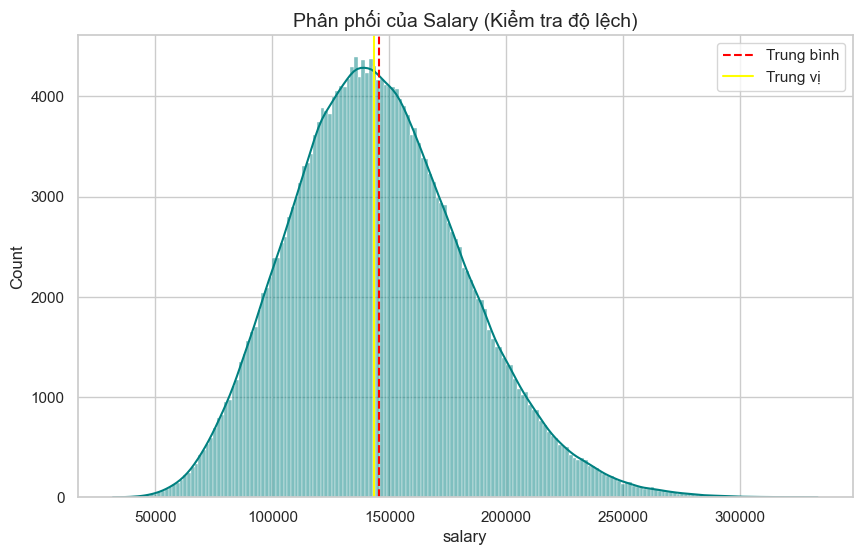

--- Báo cáo cho cột: experience_years ---
- Ngưỡng dưới: -10.00, Ngưỡng trên: 30.00
- Số lượng Outliers: 0 (0.00%)
----------------------------------------
--- Báo cáo cho cột: skills_count ---
- Ngưỡng dưới: -10.00, Ngưỡng trên: 30.00
- Số lượng Outliers: 0 (0.00%)
----------------------------------------
--- Báo cáo cho cột: certifications ---
- Ngưỡng dưới: -3.50, Ngưỡng trên: 8.50
- Số lượng Outliers: 0 (0.00%)
----------------------------------------
--- Báo cáo cho cột: salary ---
- Ngưỡng dưới: 44157.00, Ngưỡng trên: 244693.00
- Số lượng Outliers: 2336 (0.93%)
- Giá trị lớn nhất ngoại lai: 333046
- Giá trị nhỏ nhất ngoại lai: 31867
----------------------------------------


In [6]:


# Thiết lập giao diện biểu đồ
sns.set(style="whitegrid")

# 1. Tải bộ dữ liệu
df = pd.read_csv('job_salary_prediction_dataset.csv')

# 2. Danh sách các cột số cần kiểm tra
num_cols = ['experience_years', 'skills_count', 'certifications', 'salary']

# 3. TRỰC QUAN HÓA BẰNG BOXPLOT
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue', fliersize=5)
    plt.title(f'Boxplot of {col}', fontsize=14)

plt.tight_layout()
plt.show() # Hoặc plt.savefig('outliers.png')

# 4. KIỂM TRA PHÂN PHỐI LƯƠNG (SKEWNESS)
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], kde=True, color='teal')
plt.title('Phân phối của Salary (Kiểm tra độ lệch)', fontsize=14)
plt.axvline(df['salary'].mean(), color='red', linestyle='--', label='Trung bình')
plt.axvline(df['salary'].median(), color='yellow', linestyle='-', label='Trung vị')
plt.legend()
plt.show()

# 5. HÀM TÍNH TOÁN CHI TIẾT OUTLIERS THEO IQR
def report_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"--- Báo cáo cho cột: {column} ---")
    print(f"- Ngưỡng dưới: {lower_bound:.2f}, Ngưỡng trên: {upper_bound:.2f}")
    print(f"- Số lượng Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"- Giá trị lớn nhất ngoại lai: {outliers[column].max()}")
        print(f"- Giá trị nhỏ nhất ngoại lai: {outliers[column].min()}")
    print("-" * 40)

# Chạy báo cáo
for col in num_cols:
    report_outliers(df, col)

# Kiểm tra tính nhất quán ở các cột 

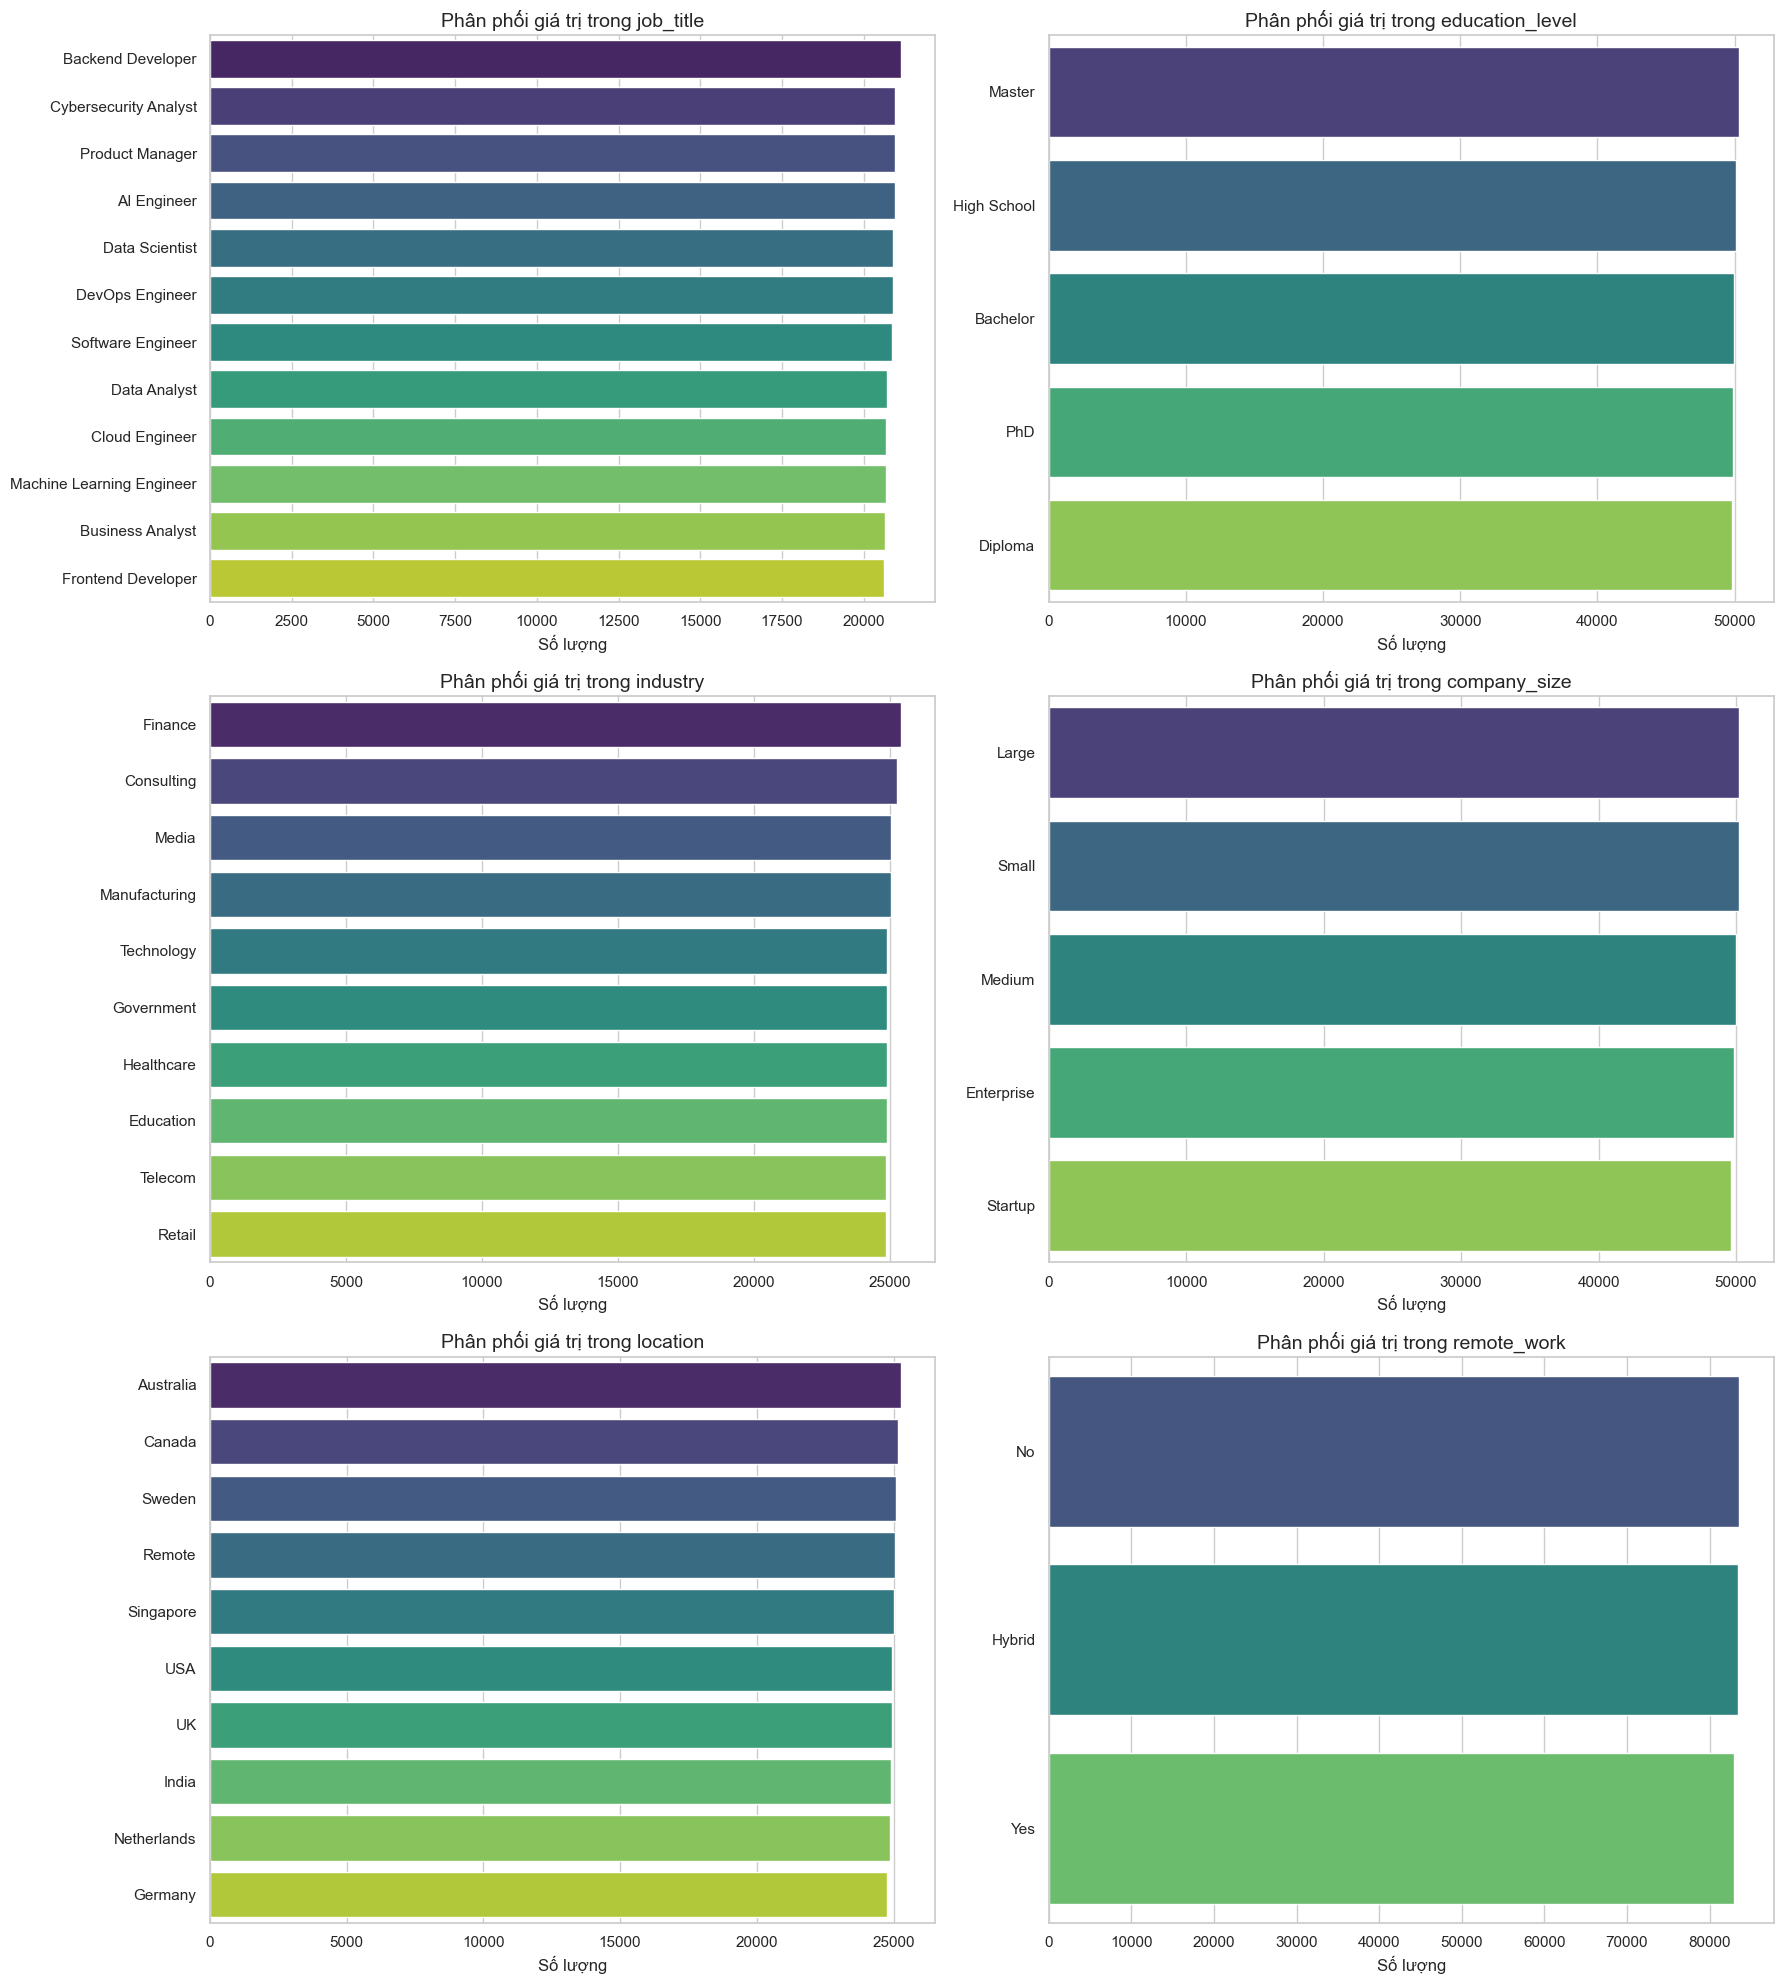

--- KIỂM TRA TÍNH BẤT NHẤT CHI TIẾT ---
Cột [job_title]:
  - Số giá trị duy nhất hiện tại: 12
  - Số giá trị sau khi chuẩn hóa: 12
  => Cột job_title sạch sẽ về định dạng.
----------------------------------------
Cột [education_level]:
  - Số giá trị duy nhất hiện tại: 5
  - Số giá trị sau khi chuẩn hóa: 5
  => Cột education_level sạch sẽ về định dạng.
----------------------------------------
Cột [industry]:
  - Số giá trị duy nhất hiện tại: 10
  - Số giá trị sau khi chuẩn hóa: 10
  => Cột industry sạch sẽ về định dạng.
----------------------------------------
Cột [company_size]:
  - Số giá trị duy nhất hiện tại: 5
  - Số giá trị sau khi chuẩn hóa: 5
  => Cột company_size sạch sẽ về định dạng.
----------------------------------------
Cột [location]:
  - Số giá trị duy nhất hiện tại: 10
  - Số giá trị sau khi chuẩn hóa: 10
  => Cột location sạch sẽ về định dạng.
----------------------------------------
Cột [remote_work]:
  - Số giá trị duy nhất hiện tại: 3
  - Số giá trị sau khi chuẩn h

In [7]:
# Các cột phân loại cần kiểm tra
cat_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

# 2. KIỂM TRA BẤT NHẤT VỀ ĐỊNH DẠNG (TRỰC QUAN)
plt.figure(figsize=(18, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    # Vẽ biểu đồ đếm số lượng từng giá trị
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Phân phối giá trị trong {col}', fontsize=14)
    plt.xlabel('Số lượng')
    plt.ylabel(None)

plt.tight_layout()
plt.show()

# 3. KIỂM TRA BẤT NHẤT VỀ CHỮ HOA/THƯỜNG VÀ KHOẢNG TRẮNG
print("--- KIỂM TRA TÍNH BẤT NHẤT CHI TIẾT ---")
for col in cat_cols:
    unique_vals = df[col].unique()
    # Kiểm tra nếu sau khi viết thường và xóa khoảng trắng mà số lượng unique giảm đi 
    # => Nghĩa là có dữ liệu bất nhất
    normalized_unique = df[col].str.lower().str.strip().unique()
    
    print(f"Cột [{col}]:")
    print(f"  - Số giá trị duy nhất hiện tại: {len(unique_vals)}")
    print(f"  - Số giá trị sau khi chuẩn hóa: {len(normalized_unique)}")
    
    if len(unique_vals) != len(normalized_unique):
        print(f"  => CẢNH BÁO: Phát hiện sự bất nhất về định dạng trong cột {col}!")
    else:
        print(f"  => Cột {col} sạch sẽ về định dạng.")
    print("-" * 40)

# 4. KIỂM TRA LOGIC (Ví dụ: Kinh nghiệm và Lương)
# Kiểm tra xem có ai kinh nghiệm âm không
inconsistent_exp = df[df['experience_years'] < 0]
print(f"Số dòng có kinh nghiệm âm: {len(inconsistent_exp)}")

# Kiểm tra Imbalance

--- BÁO CÁO MẤT CÂN BẰNG (Categorical Features) ---

Phân phối của cột [job_title]:
                           Số lượng  Tỷ lệ (%)
job_title                                     
Backend Developer             21125     8.4500
Cybersecurity Analyst         20959     8.3836
Product Manager               20950     8.3800
AI Engineer                   20945     8.3780
Data Scientist                20890     8.3560
DevOps Engineer               20889     8.3556
Software Engineer             20876     8.3504
Data Analyst                  20722     8.2888
Cloud Engineer                20686     8.2744
Machine Learning Engineer     20677     8.2708
Business Analyst              20648     8.2592
Frontend Developer            20633     8.2532

Phân phối của cột [education_level]:
                 Số lượng  Tỷ lệ (%)
education_level                     
Master              50352    20.1408
High School         50065    20.0260
Bachelor            49950    19.9800
PhD                 49857    19.942

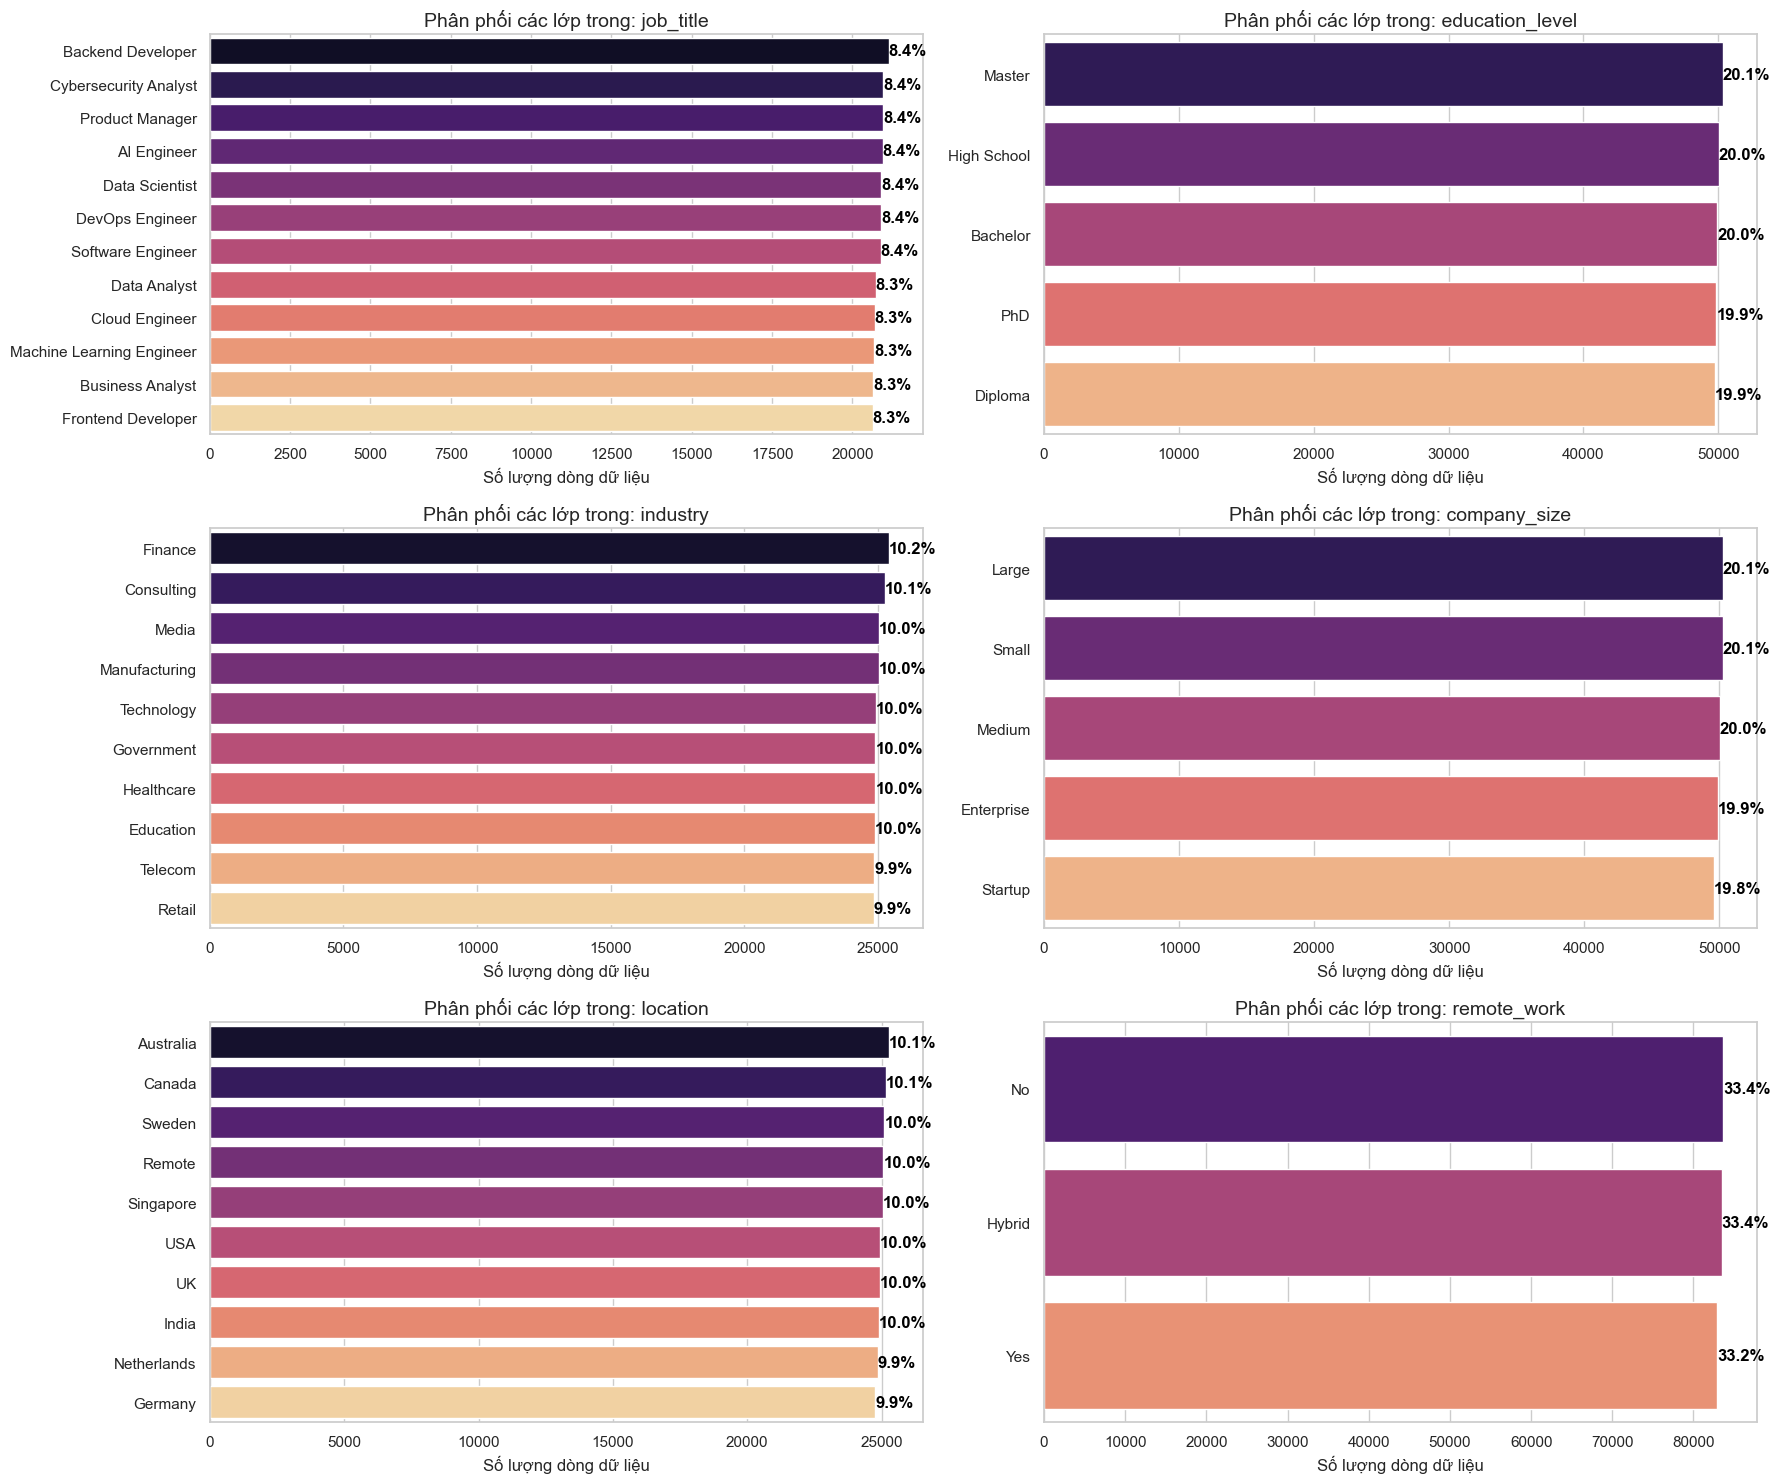

In [8]:
# Các cột phân loại cần kiểm tra
cat_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

# 1. BÁO CÁO CHI TIẾT SỐ LƯỢNG VÀ TỶ LỆ %
print("--- BÁO CÁO MẤT CÂN BẰNG (Categorical Features) ---")
for col in cat_cols:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Số lượng': counts,
        'Tỷ lệ (%)': percentages
    })
    
    print(f"\nPhân phối của cột [{col}]:")
    print(summary)
    
    # Cảnh báo nếu có nhóm chiếm hơn 50% hoặc ít hơn 5%
    if percentages.max() > 50:
        print(f"  [!] Cảnh báo: Nhóm '{percentages.idxmax()}' chiếm ưu thế quá lớn ({percentages.max():.2f}%)")
    if percentages.min() < 5:
        print(f"  [!] Lưu ý: Nhóm '{percentages.idxmin()}' có quá ít dữ liệu ({percentages.min():.2f}%)")

# 2. TRỰC QUAN HÓA BẰNG BIỂU ĐỒ CỘT (COUNT PLOT)
plt.figure(figsize=(18, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    
    # Sắp xếp theo số lượng giảm dần
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, palette='magma')
    
    # Thêm nhãn % lên đầu các cột
    total = len(df)
    for index, value in enumerate(df[col].value_counts()):
        pct = f'{100 * value / total:.1f}%'
        plt.text(value, index, pct, va='center', fontweight='bold', color='black')
        
    plt.title(f'Phân phối các lớp trong: {col}', fontsize=14)
    plt.xlabel('Số lượng dòng dữ liệu')
    plt.ylabel(None)

plt.tight_layout()
plt.show()

# Kiểm tra Skewness 

--- BÁO CÁO ĐỘ LỆCH (SKEWNESS) ---
salary: 0.3794 -> Đối xứng (Normal)
certifications: 0.0040 -> Đối xứng (Normal)
skills_count: 0.0003 -> Đối xứng (Normal)
experience_years: -0.0010 -> Đối xứng (Normal)


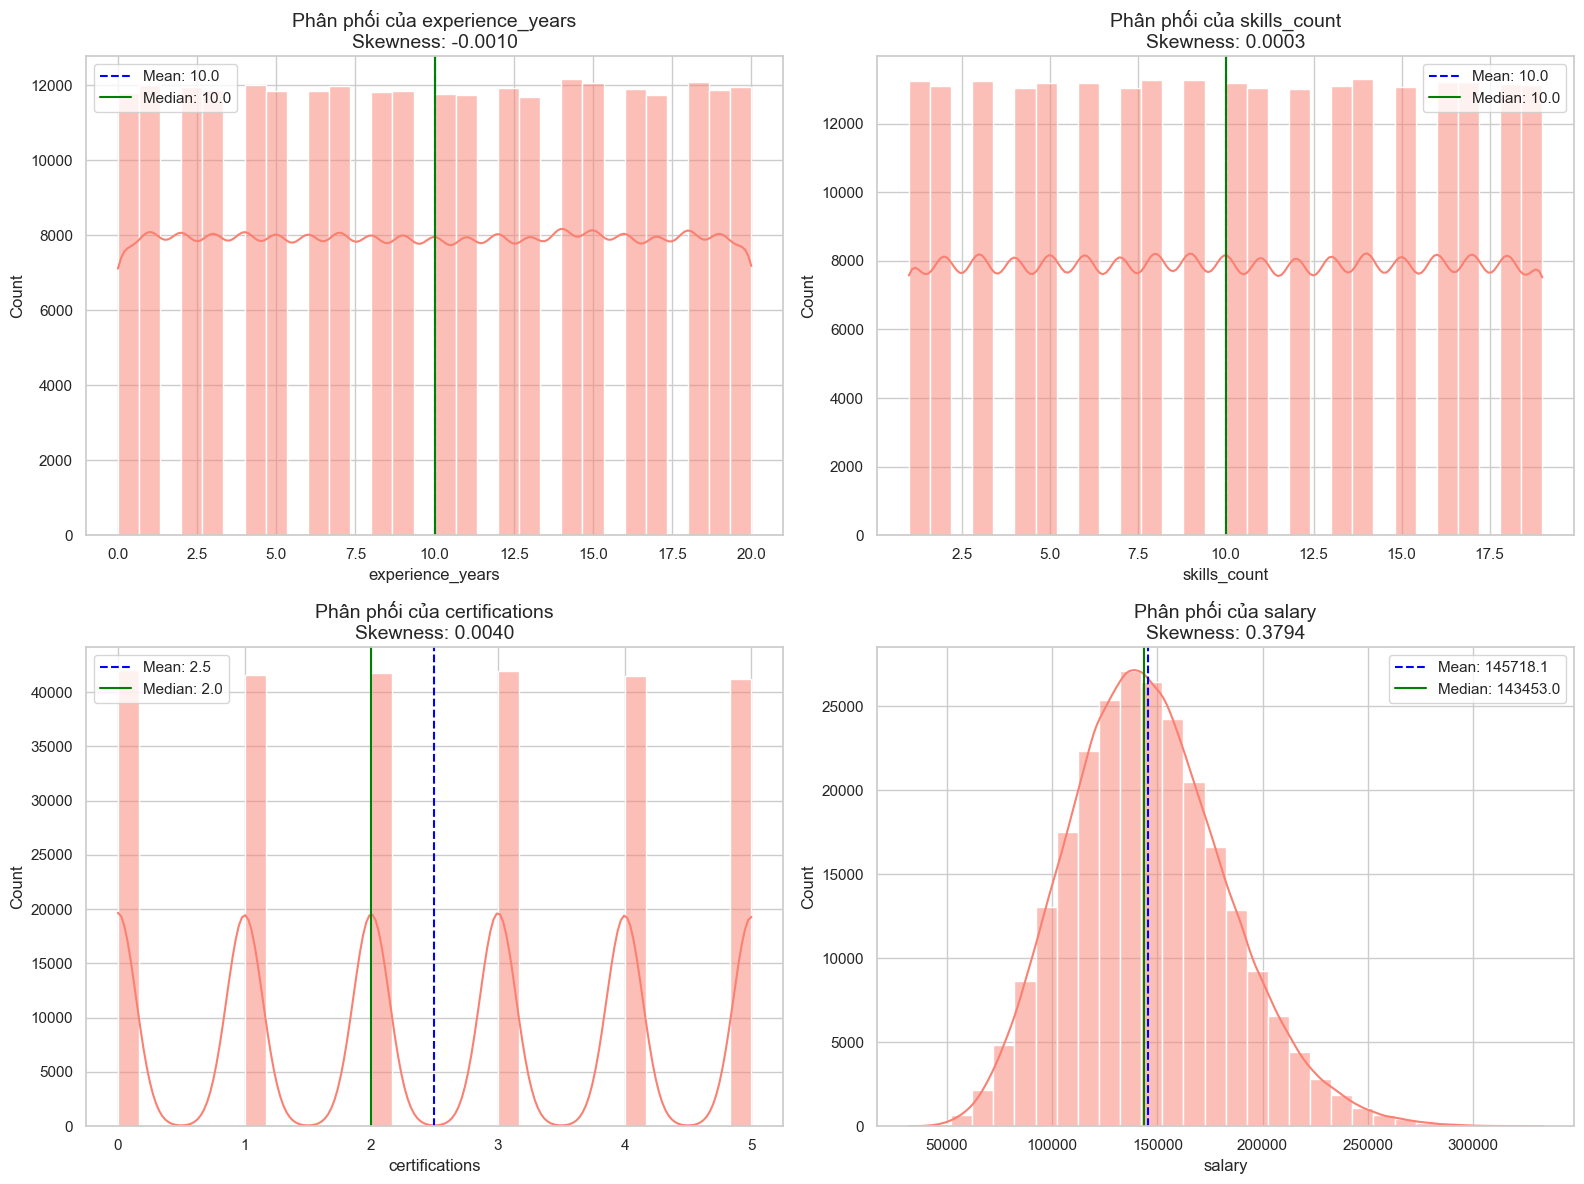

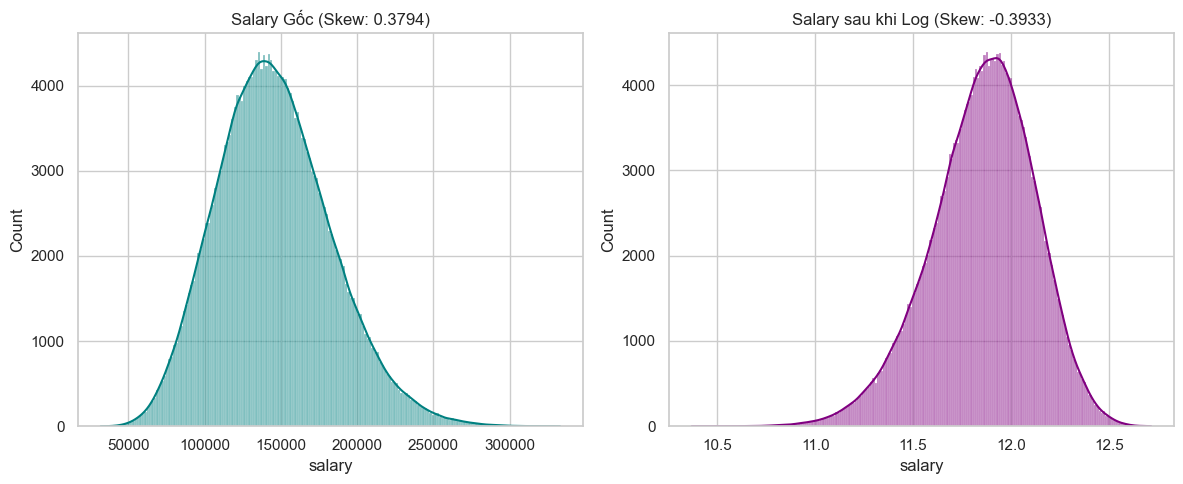

In [9]:
# 2. Lọc ra các cột dạng số
num_cols = ['experience_years', 'skills_count', 'certifications', 'salary']

# 3. Tính toán chỉ số Skewness
skewness_report = df[num_cols].skew().sort_values(ascending=False)

print("--- BÁO CÁO ĐỘ LỆCH (SKEWNESS) ---")
for col, val in skewness_report.items():
    status = "Đối xứng (Normal)"
    if val > 0.5: status = "Lệch phải (Positive Skew)"
    elif val < -0.5: status = "Lệch trái (Negative Skew)"
    print(f"{col}: {val:.4f} -> {status}")

# 4. TRỰC QUAN HÓA PHÂN PHỐI
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    
    # Vẽ biểu đồ Histogram kèm đường KDE
    sns.histplot(df[col], kde=True, color='salmon', bins=30)
    
    # Thêm đường thẳng hiển thị Mean (Trung bình) và Median (Trung vị)
    # Nếu Mean và Median trùng nhau = Dữ liệu chuẩn
    plt.axvline(df[col].mean(), color='blue', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    plt.axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.1f}')
    
    plt.title(f'Phân phối của {col}\nSkewness: {df[col].skew():.4f}', fontsize=14)
    plt.legend()

plt.tight_layout()
plt.show()

# 5. KIỂM TRA TÁC DỤNG CỦA LOG-TRANSFORM (Cho cột Salary)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['salary'], kde=True, color='teal')
plt.title(f"Salary Gốc (Skew: {df['salary'].skew():.4f})")

plt.subplot(1, 2, 2)
log_salary = np.log1p(df['salary'])
sns.histplot(log_salary, kde=True, color='purple')
plt.title(f"Salary sau khi Log (Skew: {log_salary.skew():.4f})")

plt.tight_layout()
plt.show()

## The Experience-Salary Correlation

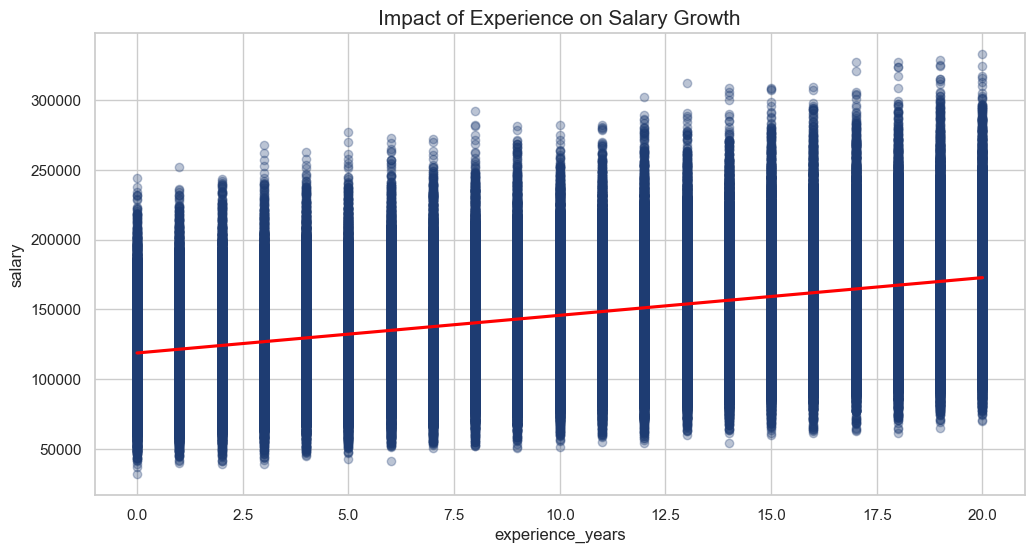

In [10]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='experience_years', y='salary', 
            scatter_kws={'alpha':0.3, 'color':'#1e3c72'}, line_kws={'color':'red'})
plt.title('Impact of Experience on Salary Growth', fontsize=15)
plt.show()

# Salary & Education

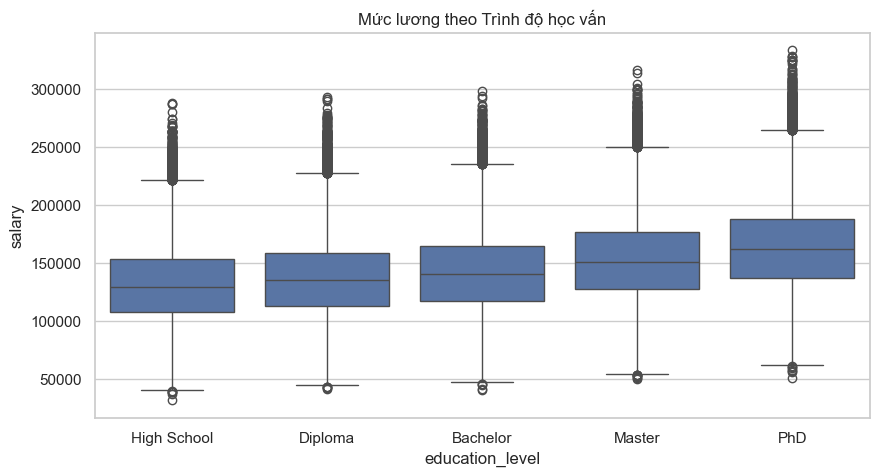

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='education_level', y='salary', 
            order=['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'])
plt.title('Mức lương theo Trình độ học vấn')
plt.show()

Biểu đồ boxplot cho thấy mức lương có xu hướng tăng theo trình độ học vấn, từ High School đến PhD.  
Nhóm có học vấn cao hơn không chỉ có median lương cao hơn mà còn có độ phân tán lớn hơn.  
Ngoài ra, xuất hiện nhiều outlier ở các mức lương cao, đặc biệt ở bậc Master và PhD.

## Role & Education

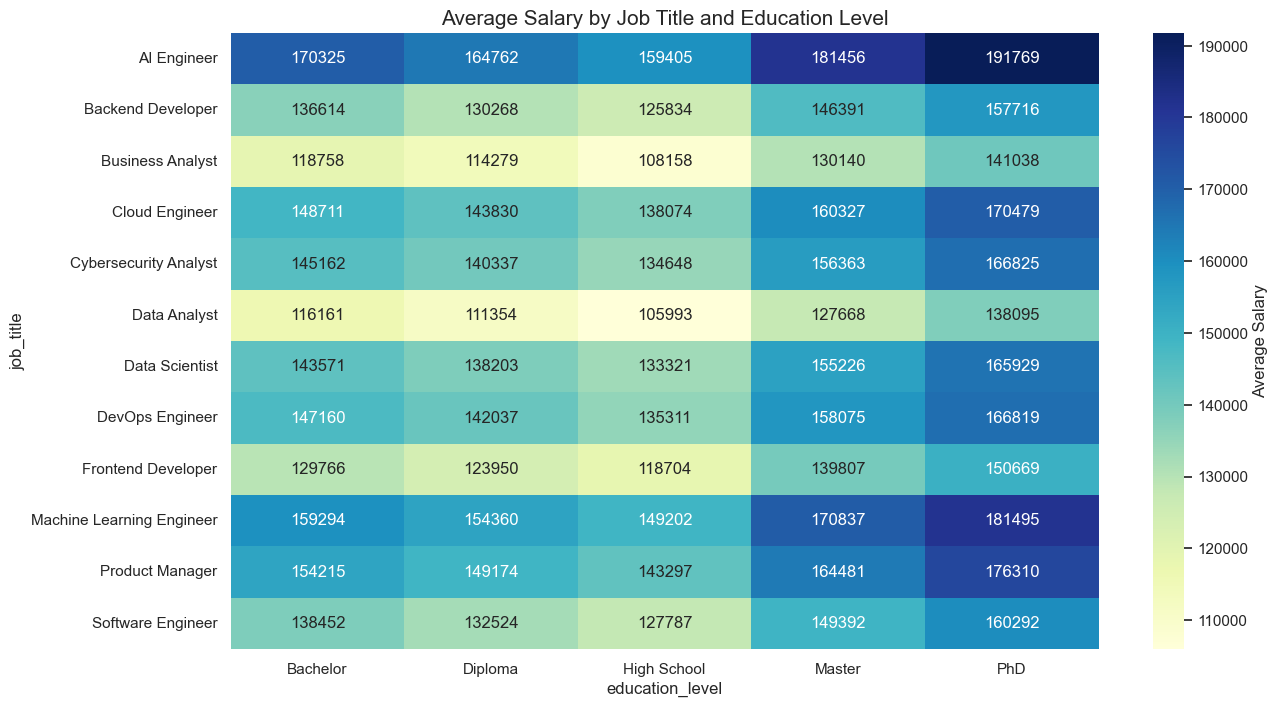

In [12]:
pivot_table = df.pivot_table(index='job_title', columns='education_level', values='salary', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average Salary'})
plt.title('Average Salary by Job Title and Education Level', fontsize=15)
plt.show()

##  Location vs. Remote Work

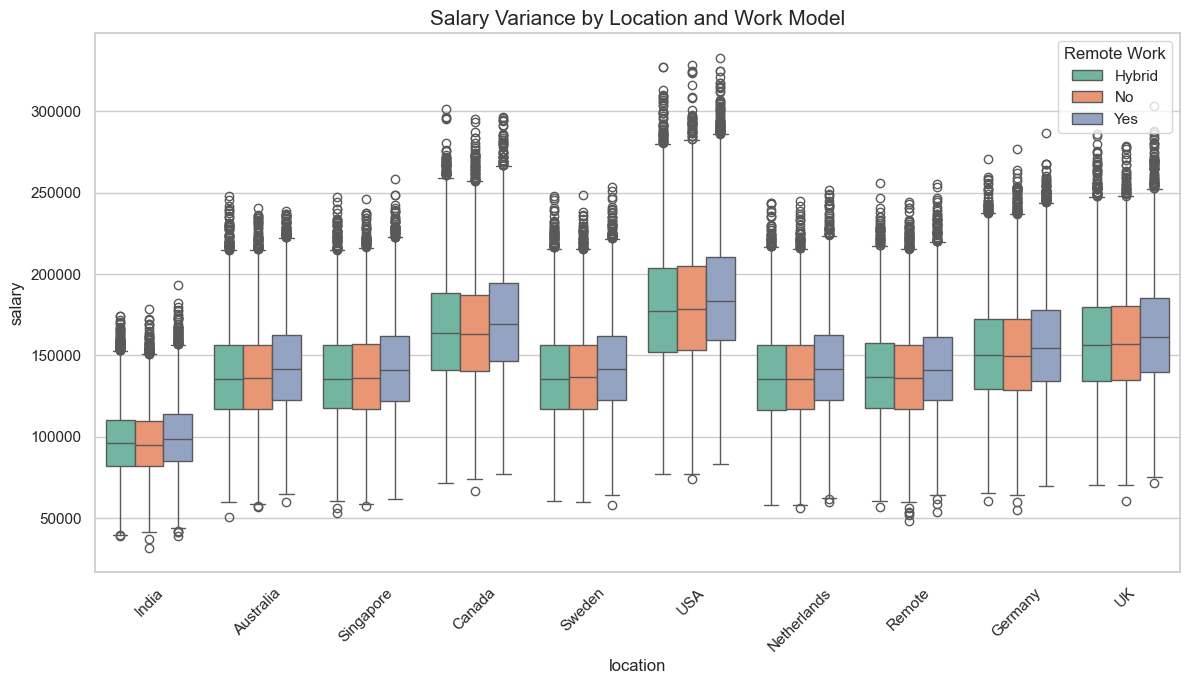

In [13]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='location', y='salary', hue='remote_work', palette='Set2')
plt.xticks(rotation=45)
plt.title('Salary Variance by Location and Work Model', fontsize=15)
plt.legend(title='Remote Work', loc='upper right')
plt.show()

# Ma trận tương quan giữa các biến 

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

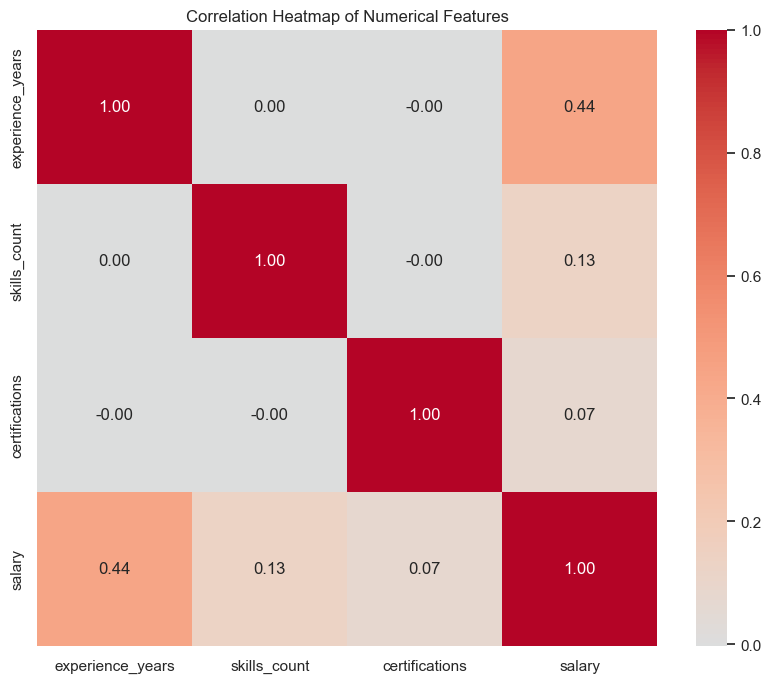

In [14]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Heatmap of Numerical Features")

- Kinh nghiệm (experience_years) có tương quan dương mức trung bình với lương (0.44), cho thấy người có nhiều kinh nghiệm thường có thu nhập cao hơn.
- Số lượng kỹ năng (skills_count) và chứng chỉ (certifications) có tương quan rất yếu với lương (0.13 và 0.07), ảnh hưởng không đáng kể.
- Các biến độc lập gần như không tương quan với nhau (~0.00), cho thấy ít xảy ra đa cộng tuyến trong mô hình.

## Feature Engineering

In [15]:

# 1. Log transform salary (giảm skew)
df["log_salary"] = np.log1p(df["salary"])


# 2. Experience level (FIX NaN bằng cách mở rộng khoảng)
bins = [-np.inf, 2, 5, 10, 15, np.inf]
labels = ["entry", "junior", "mid", "senior", "expert"]

df["experience_level"] = pd.cut(
    df["experience_years"],
    bins=bins,
    labels=labels
)


# 3. Skills level (FIX tương tự để tránh NaN)
df["skills_level"] = pd.cut(
    df["skills_count"],
    bins=[-np.inf, 5, 10, 15, np.inf],
    labels=["low", "mid", "high", "expert"]
)


# 4. Feature ratios (tránh chia cho 0)
df["skills_per_year"] = df["skills_count"] / (df["experience_years"] + 1)
df["certs_per_year"] = df["certifications"] / (df["experience_years"] + 1)


# 5. Encode education level
edu_map = {
    "High School": 0,
    "Diploma": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4
}
df["education_level_encoded"] = df["education_level"].map(edu_map)


# 6. Encode company size
size_map = {
    "Startup": 0,
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Enterprise": 4
}
df["company_size_encoded"] = df["company_size"].map(size_map)


# 7. Remote work → binary
df["is_remote"] = (df["remote_work"] == "Yes").astype(int)


# 8. Drop cột gốc (GIỮ is_remote vì đã encode xong)
df = df.drop(columns=["education_level", "company_size", "remote_work"])


# 9. (OPTIONAL nhưng nên có) xử lý missing nếu mapping bị lỗi
df["education_level_encoded"] = df["education_level_encoded"].fillna(-1)
df["company_size_encoded"] = df["company_size_encoded"].fillna(-1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   job_title                250000 non-null  object  
 1   experience_years         250000 non-null  int64   
 2   skills_count             250000 non-null  int64   
 3   industry                 250000 non-null  object  
 4   location                 250000 non-null  object  
 5   certifications           250000 non-null  int64   
 6   salary                   250000 non-null  int64   
 7   log_salary               250000 non-null  float64 
 8   experience_level         250000 non-null  category
 9   skills_level             250000 non-null  category
 10  skills_per_year          250000 non-null  float64 
 11  certs_per_year           250000 non-null  float64 
 12  education_level_encoded  250000 non-null  int64   
 13  company_size_encoded     250000 non-null  in

In [17]:
for col in df.select_dtypes(include=["object", "category"]):
    print(df[col].value_counts())

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64
experience_level
senior    59608
e

In [18]:
X = df.drop(columns="log_salary")
y = df["log_salary"]

num_features = [
    "experience_years",
    "skills_count",
    "certifications",
    "skills_per_year",
    "certs_per_year"
]

ordinal_categorical = [
    "experience_level",
    "skills_level"
]

ordinal_numeric = [
    "education_level_encoded",
    "company_size_encoded"
]

onehot_features = [
    "job_title",
    "industry",
    "location",
    "remote_work"
]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["entry", "junior", "mid", "senior", "expert", "unknown"],
            ["low", "mid", "high", "expert"]
        ]
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
    ("num", StandardScaler(), num_features),
    ("ord_cat", ordinal_pipeline, ordinal_categorical),
    ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_features),
    ("passthrough", "passthrough", ordinal_numeric)
    ]
)

In [19]:
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(exclude='number').columns.tolist(), drop_first=True, dtype=int)
df_encoded.head()

,experience_years,skills_count,certifications,salary,log_salary,skills_per_year,certs_per_year,education_level_encoded,company_size_encoded,is_remote,...,location_Sweden,location_UK,location_USA,experience_level_junior,experience_level_mid,experience_level_senior,experience_level_expert,skills_level_mid,skills_level_high,skills_level_expert
0,10,2,2,109413,11.602894,0.181818,0.181818,2,2,0,...,0,0,0,0,1,0,0,0,0,0
1,5,17,0,93764,11.448547,2.833333,0.000000,2,1,0,...,0,0,0,1,0,0,0,0,0,1
2,18,4,1,148123,11.905805,0.210526,0.052632,4,2,0,...,0,0,0,0,0,0,1,0,0,0
3,19,13,0,189123,12.150158,0.650000,0.000000,4,2,1,...,0,0,0,0,0,0,1,0,1,0
4,15,7,0,165069,12.014125,0.437500,0.000000,2,3,1,...,1,0,0,0,0,1,0,1,0,0


# Chia dữ liệu 70-15-15 


In [20]:
from sklearn.model_selection import train_test_split

# Giả sử X và y của bạn đã được chuẩn bị từ bước trước
X = df_encoded.drop(columns=["salary", "log_salary"])
y = df_encoded["log_salary"]

# BƯỚC 1: Cắt 70% cho Train, giữ lại 30% làm tập tạm thời (Temp)
# Tập Temp này sẽ chứa cả Validation và Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# BƯỚC 2: Cắt đôi tập Temp (30%) thành 2 phần bằng nhau (mỗi phần 15%)
# test_size=0.5 ở đây nghĩa là lấy 50% của tập Temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# KIỂM TRA LẠI KẾT QUẢ
print(f"Tổng số dữ liệu ban đầu: {len(X)} dòng")
print(f"-> Tập Train (70%): {len(X_train)} dòng")
print(f"-> Tập Validation (15%): {len(X_val)} dòng")
print(f"-> Tập Test (15%): {len(X_test)} dòng")

Tổng số dữ liệu ban đầu: 250000 dòng
-> Tập Train (70%): 175000 dòng
-> Tập Validation (15%): 37500 dòng
-> Tập Test (15%): 37500 dòng


# Random Forest 

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Khởi tạo model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# 2. Train trên tập Train
rf_model.fit(X_train, y_train)


# 3. Evaluate trên Validation (để tuning)
y_val_pred = rf_model.predict(X_val)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("📊 Validation Results:")
print(f"MAE  : {val_mae:.2f}")
print(f"RMSE : {val_rmse:.2f}")
print(f"R2   : {val_r2:.4f}")


# 4. Evaluate trên Test (kết quả cuối cùng)
y_test_pred = rf_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\n🏆 Test Results (Final):")
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R2   : {test_r2:.4f}")

📊 Validation Results:
MAE  : 0.04
RMSE : 0.05
R2   : 0.9607

🏆 Test Results (Final):
MAE  : 0.04
RMSE : 0.05
R2   : 0.9603


# Linear Regression 

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import Ridge

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# 2. Train model
lr_model.fit(X_train, y_train)


# 3. Đánh giá trên Validation
y_val_pred = lr_model.predict(X_val)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("📊 Validation Results (Linear Regression):")
print(f"MAE  : {val_mae:.2f}")
print(f"RMSE : {val_rmse:.2f}")
print(f"R2   : {val_r2:.4f}")


# 4. Đánh giá trên Test (kết quả cuối)
y_test_pred = lr_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\n🏆 Test Results (Linear Regression):")
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R2   : {test_r2:.4f}")

📊 Validation Results (Linear Regression):
MAE  : 0.04
RMSE : 0.05
R2   : 0.9688

🏆 Test Results (Linear Regression):
MAE  : 0.04
RMSE : 0.05
R2   : 0.9684


# Ridge Regression

In [23]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------
# 1. Chuẩn hóa dữ liệu
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 2. Ridge Regression
# -----------------------------
# Tham số alpha (lambda) điều chỉnh mức độ Regularization
ridge_model = Ridge(alpha=1.0)  
ridge_model.fit(X_train_scaled, y_train)

# Dự đoán
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_val_pred_ridge = ridge_model.predict(X_val_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Đánh giá
print("=== Ridge Regression ===")
print(f"Train R2: {r2_score(y_train, y_train_pred_ridge):.4f}")
print(f"Validation R2: {r2_score(y_val, y_val_pred_ridge):.4f}")
print(f"Test R2: {r2_score(y_test, y_test_pred_ridge):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)):.4f}\n")

=== Ridge Regression ===
Train R2: 0.9686
Validation R2: 0.9688
Test R2: 0.9684
Test RMSE: 0.0470



# Decision Tree Regression

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------
# 1. Tạo Decision Tree Regression
# -----------------------------
# Bạn có thể thay đổi max_depth để kiểm soát overfitting
dt_model = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_model.fit(X_train, y_train)

# -----------------------------
# 2. Dự đoán
# -----------------------------
y_train_pred_dt = dt_model.predict(X_train)
y_val_pred_dt = dt_model.predict(X_val)
y_test_pred_dt = dt_model.predict(X_test)

# -----------------------------
# 3. Đánh giá
# -----------------------------
print("=== Decision Tree Regression ===")
print(f"Train R2: {r2_score(y_train, y_train_pred_dt):.4f}")
print(f"Validation R2: {r2_score(y_val, y_val_pred_dt):.4f}")
print(f"Test R2: {r2_score(y_test, y_test_pred_dt):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_dt)):.4f}")

=== Decision Tree Regression ===
Train R2: 1.0000
Validation R2: 0.9172
Test R2: 0.9171
Test RMSE: 0.0762


# Gradient Boosting

In [25]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------
# 1. Tạo Gradient Boosting Regression
# -----------------------------
# Tham số bạn có thể tune: n_estimators, learning_rate, max_depth
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# -----------------------------
# 2. Dự đoán
# -----------------------------
y_train_pred_gb = gb_model.predict(X_train)
y_val_pred_gb = gb_model.predict(X_val)
y_test_pred_gb = gb_model.predict(X_test)

# -----------------------------
# 3. Đánh giá
# -----------------------------
print("=== Gradient Boosting Regression ===")
print(f"Train R2: {r2_score(y_train, y_train_pred_gb):.4f}")
print(f"Validation R2: {r2_score(y_val, y_val_pred_gb):.4f}")
print(f"Test R2: {r2_score(y_test, y_test_pred_gb):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_gb)):.4f}")

=== Gradient Boosting Regression ===
Train R2: 0.9765
Validation R2: 0.9755
Test R2: 0.9752
Test RMSE: 0.0417


# XGBoost 


In [26]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Khởi tạo model (đặt early stopping tại đây)
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=20   # 🔥 đặt ở đây (KHÔNG phải trong fit)
)

# 2. Train model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 3. Predict
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

# 4. Evaluate
print("Validation R2:", r2_score(y_val, y_val_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Validation R2: 0.9755172986558894
Test R2: 0.9752466003966934


# So sánh điểm 6 models 

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import time
# -----------------------------
# 1. Chuẩn hóa dữ liệu cho Linear/Ridge/Lasso (cần scale)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 2. Khởi tạo các model
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=None, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, verbosity=0)
}

# -----------------------------
# 3. Train, predict và đánh giá
# -----------------------------
results = []

for name, model in models.items():
    # Chọn dữ liệu scale hay không
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        X_tr, X_vl, X_te = X_train_scaled, X_val_scaled, X_test_scaled
    else:
        X_tr, X_vl, X_te = X_train, X_val, X_test
    
    # Đo thời gian huấn luyện
    start_time = time.time()
    model.fit(X_tr, y_train)
    execution_time = time.time() - start_time
    
    # Predict
    y_pred_train = model.predict(X_tr)
    y_pred_val = model.predict(X_vl)
    y_pred_test = model.predict(X_te)
    
    # Tính R2 và RMSE
    results.append({
        "Model": name,
        "Train R2": r2_score(y_train, y_pred_train),
        "Validation R2": r2_score(y_val, y_pred_val),
        "Test R2": r2_score(y_test, y_pred_test),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Time (s)": round(execution_time, 4)
    })

# -----------------------------
# 4. In bảng so sánh
# -----------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print(results_df)

               Model  Train R2  Validation R2   Test R2  Test RMSE  Time (s)
0            XGBoost  0.976564       0.975473  0.975280   0.041615    2.1498
1  Gradient Boosting  0.976527       0.975470  0.975181   0.041698  191.0572
2  Linear Regression  0.968568       0.968814  0.968449   0.047014    0.1655
3   Ridge Regression  0.968568       0.968814  0.968449   0.047014    0.0838
4      Decision Tree  0.999987       0.917160  0.917098   0.076209    2.0320
5      Random Forest  0.849280       0.844020  0.844293   0.104443  109.0005


# K- Fold cho model Random Forest 

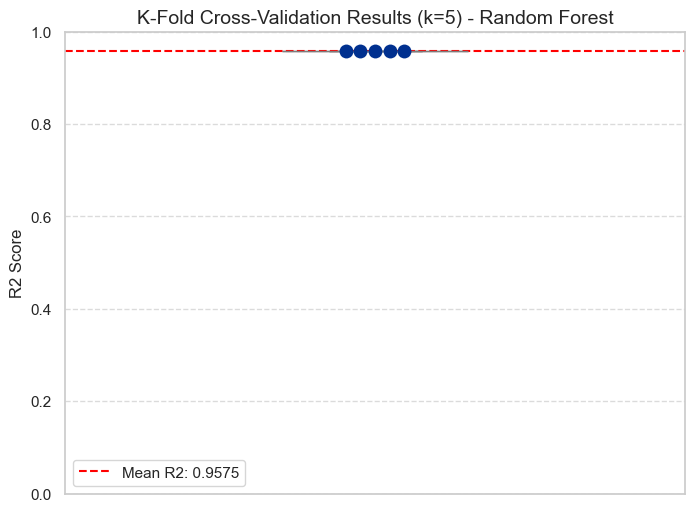

Scores từng fold: [0.95769727 0.95767932 0.95679271 0.95715019 0.9582119 ]
R2 Trung bình: 0.9575 (+/- 0.0005)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor

# 1. Khởi tạo mô hình và cơ chế K-Fold
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Tính toán Score (ví dụ dùng R2 score)
# Lưu ý: Bạn có thể thay X_train, y_train bằng tập dữ liệu gộp (Train + Val) 
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2')

# 3. Trực quan hóa
plt.figure(figsize=(8, 6))

# Vẽ Boxplot để thấy phân phối tổng quát
sns.boxplot(y=cv_scores, color='#a2d2ff', width=0.3)

# Vẽ Swarmplot để thấy từng điểm số của 5 Fold cụ thể
sns.swarmplot(y=cv_scores, color='#00308f', size=10)

# Thêm các đường chỉ số trung bình
mean_score = np.mean(cv_scores)
plt.axhline(y=mean_score, color='red', linestyle='--', label=f'Mean R2: {mean_score:.4f}')

# Tinh chỉnh giao diện
plt.title('K-Fold Cross-Validation Results (k=5) - Random Forest', fontsize=14)
plt.ylabel('R2 Score')
plt.ylim(0, 1) # Giới hạn trục y từ 0 đến 1 để dễ quan sát
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# In kết quả chi tiết
print(f"Scores từng fold: {cv_scores}")
print(f"R2 Trung bình: {mean_score:.4f} (+/- {np.std(cv_scores):.4f})")

# K-Fold cho XGBoost

Fold       | R2 Score     | Time (s)  
-----------------------------------
Fold 1     | 0.9752       | 2.3938    
Fold 2     | 0.9752       | 2.5111    
Fold 3     | 0.9749       | 1.8629    
Fold 4     | 0.9751       | 1.9840    
Fold 5     | 0.9754       | 2.1639    


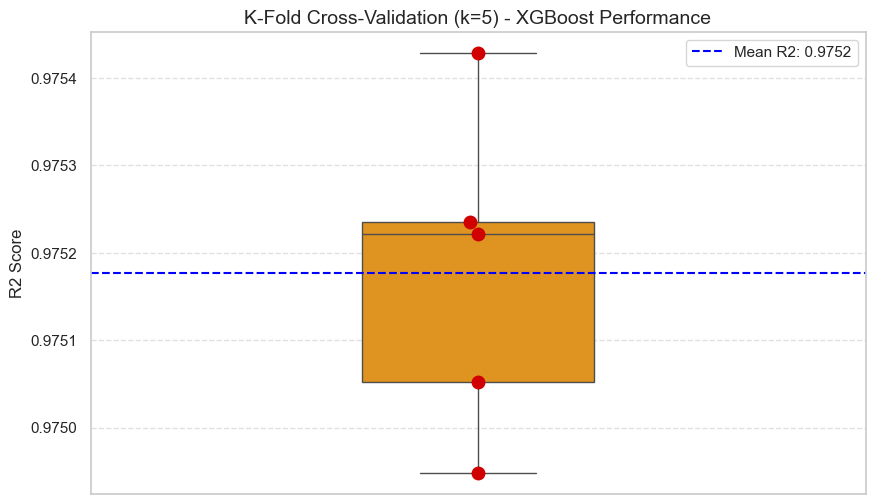

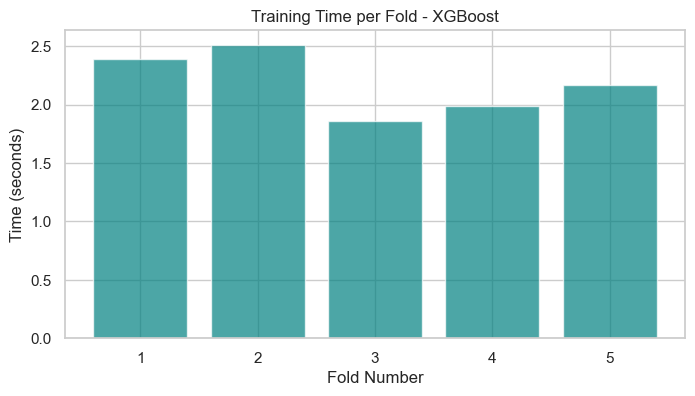


Thời gian trung bình mỗi fold: 2.1831 giây


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. Khởi tạo mô hình và cơ chế K-Fold
# Giữ nguyên tham số bạn đã dùng ở phần so sánh trước đó
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, verbosity=0)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Chạy K-Fold thủ công để đo thời gian từng Fold
fold_scores = []
fold_times = []

print(f"{'Fold':<10} | {'R2 Score':<12} | {'Time (s)':<10}")
print("-" * 35)

# X_train, y_train là dữ liệu bạn đã chia ở bước 70/15/15
# Lưu ý: XGBoost không nhất thiết cần data scaled, dùng X_train gốc là ổn
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    start_time = time.time()
    
    # Huấn luyện
    xgb_model.fit(X_fold_train, y_fold_train)
    
    elapsed_time = time.time() - start_time
    
    # Dự đoán và tính điểm
    y_pred = xgb_model.predict(X_fold_val)
    score = r2_score(y_fold_val, y_pred)
    
    fold_scores.append(score)
    fold_times.append(elapsed_time)
    
    print(f"Fold {i+1:<5} | {score:<12.4f} | {elapsed_time:<10.4f}")

# 3. Trực quan hóa kết quả
plt.figure(figsize=(10, 6))

# Vẽ các điểm điểm số của XGBoost
sns.boxplot(y=fold_scores, color='#ff9a00', width=0.3)
sns.swarmplot(y=fold_scores, color='#d00000', size=10)

# Đường trung bình
mean_r2 = np.mean(fold_scores)
plt.axhline(y=mean_r2, color='blue', linestyle='--', label=f'Mean R2: {mean_r2:.4f}')

plt.title('K-Fold Cross-Validation (k=5) - XGBoost Performance', fontsize=14)
plt.ylabel('R2 Score')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# 4. Trực quan hóa thời gian chạy
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), fold_times, color='teal', alpha=0.7)
plt.title('Training Time per Fold - XGBoost')
plt.xlabel('Fold Number')
plt.ylabel('Time (seconds)')
plt.show()

print(f"\nThời gian trung bình mỗi fold: {np.mean(fold_times):.4f} giây")

# LossValidation của GradientBoostRegression 

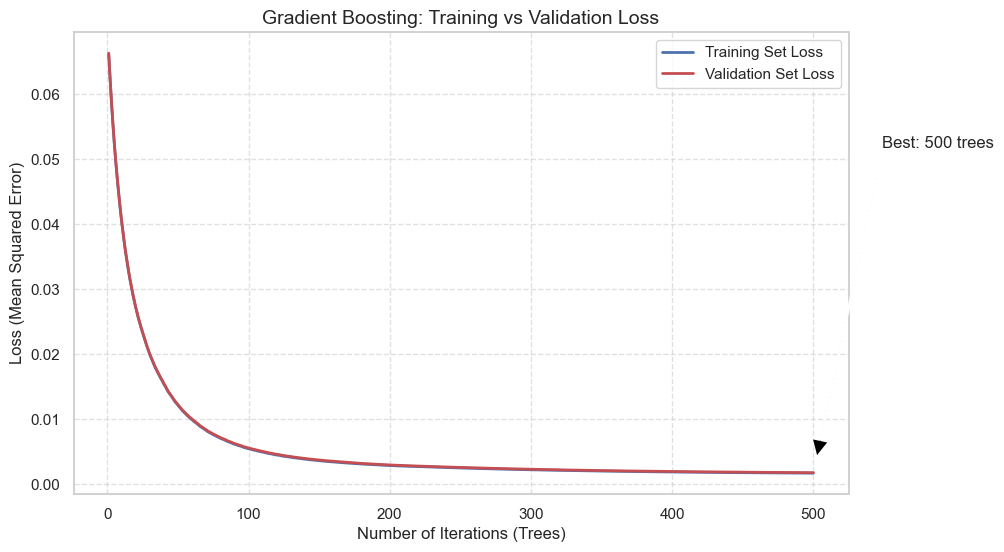

Số lượng cây tối ưu nhất cho mô hình là: 500


In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Khởi tạo và huấn luyện mô hình
# Lưu ý: n_estimators nên để đủ lớn (ví dụ 500) để thấy rõ điểm hội tụ
gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
gbr.fit(X_train, y_train)

# 2. Tính toán Loss trên tập Validation qua từng vòng lặp (staged_predict)
val_score = np.zeros((500,), dtype=np.float64)
for i, y_pred in enumerate(gbr.staged_predict(X_val)):
    val_score[i] = mean_squared_error(y_val, y_pred)

# 3. Trực quan hóa
plt.figure(figsize=(10, 6))

# Đường Loss của tập Train (có sẵn trong model sau khi fit)
plt.plot(np.arange(500) + 1, gbr.train_score_, 'b-', label='Training Set Loss', linewidth=2)

# Đường Loss của tập Validation (vừa tính toán ở trên)
plt.plot(np.arange(500) + 1, val_score, 'r-', label='Validation Set Loss', linewidth=2)

# Tinh chỉnh biểu đồ
plt.title('Gradient Boosting: Training vs Validation Loss', fontsize=14)
plt.xlabel('Number of Iterations (Trees)')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Đánh dấu điểm thấp nhất của Validation Loss
min_val_loss_idx = np.argmin(val_score)
min_val_loss = val_score[min_val_loss_idx]
plt.annotate(f'Best: {min_val_loss_idx+1} trees', 
             xy=(min_val_loss_idx+1, min_val_loss), 
             xytext=(min_val_loss_idx+50, min_val_loss + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

print(f"Số lượng cây tối ưu nhất cho mô hình là: {min_val_loss_idx + 1}")

# Loss- Validation của XGBoostRegression 

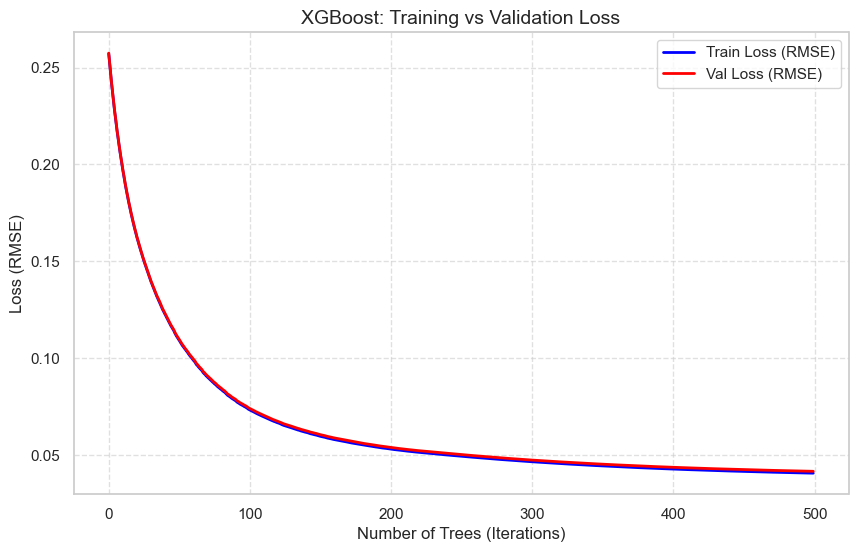

In [34]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# 1. Khởi tạo mô hình
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42,
    verbosity=0
)

# 2. Huấn luyện với tập đánh giá (eval_set) để ghi lại lịch sử Loss
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# 3. Trích xuất kết quả Loss (RMSE)
results = xgb_model.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']
epochs = range(0, len(train_rmse))

# 4. Trực quan hóa bằng biểu đồ đường
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_rmse, label='Train Loss (RMSE)', color='blue', linewidth=2)
plt.plot(epochs, val_rmse, label='Val Loss (RMSE)', color='red', linewidth=2)

plt.title('XGBoost: Training vs Validation Loss', fontsize=14)
plt.xlabel('Number of Trees (Iterations)')
plt.ylabel('Loss (RMSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Trực quan Bias của LinearRegression 

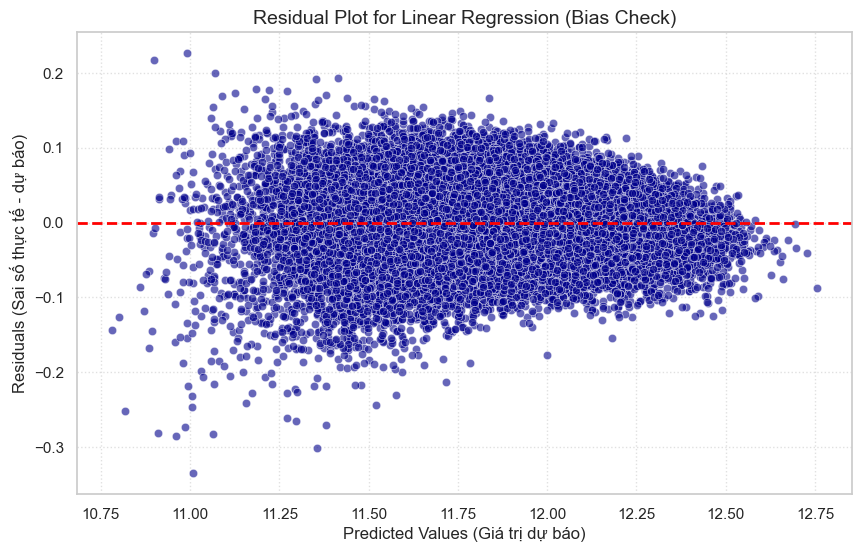

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Huấn luyện mô hình Linear Regression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Dự báo trên tập Test
y_pred = lr_model.predict(X_test_scaled)

# 3. Tính toán phần dư (Residuals)
residuals = y_test - y_pred

# 4. Vẽ biểu đồ Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='darkblue')

# Vẽ đường y=0 (Đường tham chiếu lý tưởng)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Tinh chỉnh giao diện
plt.title('Residual Plot for Linear Regression (Bias Check)', fontsize=14)
plt.xlabel('Predicted Values (Giá trị dự báo)', fontsize=12)
plt.ylabel('Residuals (Sai số thực tế - dự báo)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Bias của RidgeRegression

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge

# 1. Huấn luyện mô hình Ridge Regression (Sử dụng dữ liệu đã Scale)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 2. Dự báo trên tập Test
y_pred_ridge = ridge_model.predict(X_test_scaled)

# 3. Tính toán phần dư (Residuals)
residuals_ridge = y_test - y_pred_ridge

# 4. Vẽ biểu đồ Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, alpha=0.6, color='darkorange')

# Vẽ đường y=0 (Đường tham chiếu lý tưởng)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Tinh chỉnh giao diện
plt.title('Residual Plot for Ridge Regression (Bias Check)', fontsize=14)
plt.xlabel('Predicted Values (Giá trị dự báo)', fontsize=12)
plt.ylabel('Residuals (Sai số)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()